# Multichannel Neural Signal Analysis

## Objective

Investigate whether temporal similarity can recover candidate recording groups in 12-channel tetrode electrophysiological recordings. Compare a correlation-based solution with independent-component structure, then describe the grouped signals in time and frequency.


## Methods

### Recording input and analysis settings

The analysis uses a 12-channel, 10,000-sample recording at 1,000 Hz, corresponding to 10 seconds. The grouping model assumes three tetrodes with four channels each.

No recording is bundled. To rerun the analysis, set `NEURAL_RECORDING_PATH` to an authorized local NumPy file before launching Jupyter; see the [data documentation](../data/README.md). Saved outputs remain viewable without that file.


In [103]:
import os
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from scipy.optimize import linear_sum_assignment

from sklearn.decomposition import FastICA, PCA
from sklearn.metrics import adjusted_rand_score

# Basic dataset information
FS = 1000
EXPECTED_N_CHANNELS = 12
EXPECTED_N_TIMEPOINTS = 10000
RANDOM_STATE = 42

# Correlation-distance setting.
# False means D = 1 - r, which treats positive correlation as similarity.
# This is more appropriate here because channels from the same tetrode are expected to be positively correlated.
USE_ABSOLUTE_CORRELATION = False

print("Libraries imported successfully.")

Libraries imported successfully.


In [104]:
# Load a user-supplied local tetrode recording; no recording is bundled.
DATA_PATH = os.environ.get("NEURAL_RECORDING_PATH")
if not DATA_PATH:
    raise FileNotFoundError(
        "Set NEURAL_RECORDING_PATH to an authorized local NumPy recording "
        "before starting Jupyter. See ../data/README.md. "
        "Saved results remain available without the recording."
    )
if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError("NEURAL_RECORDING_PATH does not point to a local file.")

X = np.load(DATA_PATH, allow_pickle=False)

print("Loaded local recording.")
print("Raw X shape:", X.shape)
print("Raw X dtype:", X.dtype)

Loaded local recording.
Raw X shape: (12, 10000)
Raw X dtype: float64


### Orientation and normalization

Rows represent recording channels and columns represent samples. The preprocessing checks the array dimensions, transposes a samples-by-channels input when needed, converts values to floating point, and standardizes each channel across time.


In [105]:
# Convert to float for numerical analysis.
X = np.asarray(X, dtype=float)

# Expected shape is channels × time = 12 × 10000.
# If the file is accidentally saved as 10000 × 12, transpose it.
if X.shape == (EXPECTED_N_TIMEPOINTS, EXPECTED_N_CHANNELS):
    print("Detected shape 10000 × 12. Transposing to 12 × 10000.")
    X = X.T

if X.shape != (EXPECTED_N_CHANNELS, EXPECTED_N_TIMEPOINTS):
    raise ValueError(
        f"Unexpected data shape: {X.shape}. "
        f"Expected {(EXPECTED_N_CHANNELS, EXPECTED_N_TIMEPOINTS)}."
    )

n_channels, n_timepoints = X.shape
duration = n_timepoints / FS
time = np.arange(n_timepoints) / FS

print(f"Final X shape: {X.shape}")
print(f"Number of channels: {n_channels}")
print(f"Number of time points: {n_timepoints}")
print(f"Sampling frequency: {FS} Hz")
print(f"Duration: {duration:.2f} s")

# Z-score each channel across time.
# axis=1 means each row/channel is standardized over its time points.
channel_means = X.mean(axis=1, keepdims=True)
channel_stds = X.std(axis=1, ddof=1, keepdims=True)

if np.any(channel_stds == 0):
    raise ValueError("At least one channel has zero standard deviation and cannot be z-scored.")

X_z = (X - channel_means) / channel_stds

# Verify preprocessing.
print("\nAfter z-scoring:")
print("Mean of each channel:")
print(np.round(X_z.mean(axis=1), 6))
print("Standard deviation of each channel:")
print(np.round(X_z.std(axis=1, ddof=1), 6))

Final X shape: (12, 10000)
Number of channels: 12
Number of time points: 10000
Sampling frequency: 1000 Hz
Duration: 10.00 s

After z-scoring:
Mean of each channel:
[ 0. -0.  0.  0. -0.  0. -0. -0.  0.  0.  0. -0.]
Standard deviation of each channel:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


The saved preprocessing output confirms a 12 × 10,000 matrix. Channel-wise z-scoring removes differences in mean and scale, allowing subsequent analyses to emphasize temporal structure. The same standardized matrix feeds correlation, component analysis, group averaging, and spectral estimation.


### Similarity-based grouping

Pearson correlation provides a pairwise measure of temporal similarity. The working hypothesis is that channels sharing a local recording source have stronger correlations. Hierarchical clustering explores this structure before a balanced grouping step applies the three-by-four recording model.


The correlation heatmap displays the original channel order. Diagonal entries equal one, and warmer off-diagonal values indicate stronger positive similarity between distinct channels.


Correlation matrix shape: (12, 12)


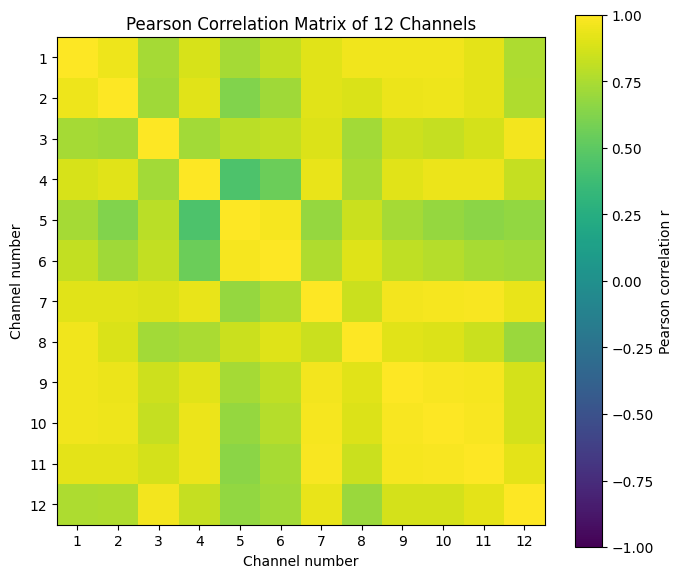

In [106]:
# Compute Pearson correlation matrix among the 12 channels.
corr_matrix = np.corrcoef(X_z)

print("Correlation matrix shape:", corr_matrix.shape)

channel_labels = np.arange(1, n_channels + 1)

plt.figure(figsize=(7, 6))
im = plt.imshow(corr_matrix, vmin=-1, vmax=1, aspect="equal")
plt.colorbar(im, label="Pearson correlation r")
plt.title("Pearson Correlation Matrix of 12 Channels")
plt.xlabel("Channel number")
plt.ylabel("Channel number")
plt.xticks(range(n_channels), channel_labels)
plt.yticks(range(n_channels), channel_labels)
plt.tight_layout()
plt.show()

A dendrogram summarizes hierarchical relationships using correlation distance. An unconstrained cut can produce unequal group sizes, so the tree is used to explore similarity rather than enforce the recording model.


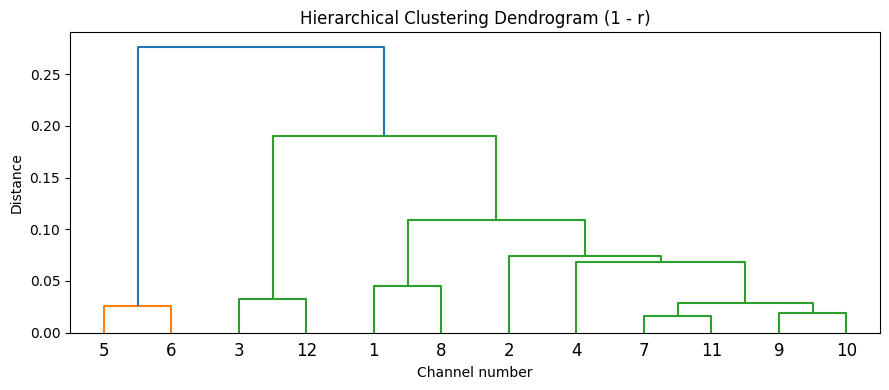

Raw unconstrained hierarchical clustering result:
Cluster 1: channels [5, 6], size = 2
Cluster 2: channels [3, 12], size = 2
Cluster 3: channels [1, 2, 4, 7, 8, 9, 10, 11], size = 8

Note: This raw hierarchical result is exploratory and does not enforce the known tetrode constraint of exactly four channels per candidate recording group.


In [107]:
# Convert the Pearson correlation matrix to a distance matrix.
# By default, D = 1 - r is used because channels from the same tetrode are expected
# to show positive temporal similarity.
# If USE_ABSOLUTE_CORRELATION is set to True, D = 1 - |r| will be used instead.

if USE_ABSOLUTE_CORRELATION:
    similarity_matrix = np.abs(corr_matrix)
    distance_matrix = 1.0 - similarity_matrix
    distance_name = "1 - |r|"
else:
    similarity_matrix = corr_matrix.copy()
    distance_matrix = 1.0 - similarity_matrix
    distance_name = "1 - r"

# Ensure distance matrix is symmetric and has zero diagonal.
distance_matrix = (distance_matrix + distance_matrix.T) / 2
np.fill_diagonal(distance_matrix, 0.0)
distance_matrix = np.clip(distance_matrix, 0.0, None)

condensed_distance = squareform(distance_matrix, checks=False)

Z = linkage(condensed_distance, method="average")

plt.figure(figsize=(9, 4))
dendrogram(Z, labels=[str(i + 1) for i in range(n_channels)])
plt.title(f"Hierarchical Clustering Dendrogram ({distance_name})")
plt.xlabel("Channel number")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Raw hierarchical clustering into 3 clusters.
# This is an unconstrained result and does not force each group to contain exactly 4 channels.
raw_hier_labels = fcluster(Z, t=3, criterion="maxclust")

raw_hier_groups = []
for lab in sorted(np.unique(raw_hier_labels)):
    raw_hier_groups.append(sorted(np.where(raw_hier_labels == lab)[0].tolist()))

print("Raw unconstrained hierarchical clustering result:")
for i, group in enumerate(raw_hier_groups, start=1):
    group_1based = [ch + 1 for ch in group]
    print(f"Cluster {i}: channels {group_1based}, size = {len(group)}")

print(
    "\nNote: This raw hierarchical result is exploratory and does not enforce the known "
    "tetrode constraint of exactly four channels per candidate recording group."
)

The balanced correlation search partitions channels into three groups of four. This introduces the assumed tetrode structure explicitly, rather than expecting hierarchical clustering to recover equal group sizes on its own.


In [108]:
def labels_from_groups(groups, n):
    labels = np.empty(n, dtype=int)
    for gi, group in enumerate(groups):
        for ch in group:
            labels[ch] = gi
    return labels


def score_grouping(groups, similarity):
    """
    Score a grouping using:
    mean within-group similarity - mean between-group similarity.
    """
    n = similarity.shape[0]
    labels = labels_from_groups(groups, n)

    within_vals = []
    between_vals = []
    group_intra_means = []

    for group in groups:
        vals = []
        for i, j in itertools.combinations(group, 2):
            vals.append(similarity[i, j])
            within_vals.append(similarity[i, j])
        group_intra_means.append(np.mean(vals))

    for i, j in itertools.combinations(range(n), 2):
        if labels[i] != labels[j]:
            between_vals.append(similarity[i, j])

    mean_intra = float(np.mean(within_vals))
    mean_inter = float(np.mean(between_vals))
    diff = mean_intra - mean_inter

    return mean_intra, mean_inter, diff, group_intra_means


def balanced_correlation_partition(similarity, group_size=4, n_groups=3):
    """
    Exhaustively search all unique partitions of 12 channels into 3 groups of 4.
    The number of unique partitions is small:
    C(12,4) * C(8,4) / 3! = 5775.
    """
    n = similarity.shape[0]
    channels = tuple(range(n))

    best_score = -np.inf
    best_groups = None
    best_metrics = None

    def recurse(remaining, current_groups):
        nonlocal best_score, best_groups, best_metrics

        if len(current_groups) == n_groups - 1:
            last_group = tuple(remaining)
            if len(last_group) == group_size:
                groups = current_groups + [last_group]
                mean_intra, mean_inter, diff, group_intra_means = score_grouping(groups, similarity)

                if diff > best_score:
                    best_score = diff
                    best_groups = [list(g) for g in groups]
                    best_metrics = {
                        "mean_intra": mean_intra,
                        "mean_inter": mean_inter,
                        "difference": diff,
                        "group_intra_means": group_intra_means,
                    }
            return

        first = remaining[0]
        rest = remaining[1:]

        for comb in itertools.combinations(rest, group_size - 1):
            group = tuple(sorted((first,) + comb))
            new_remaining = tuple(ch for ch in remaining if ch not in group)
            recurse(new_remaining, current_groups + [group])

    recurse(channels, [])

    # Sort groups internally and externally for readable display.
    best_groups = [sorted(g) for g in best_groups]
    best_groups = sorted(best_groups, key=lambda g: g[0])

    return best_groups, best_metrics


corr_groups, corr_group_metrics = balanced_correlation_partition(
    similarity_matrix,
    group_size=4,
    n_groups=3
)

print("Final correlation-based balanced grouping (channel numbers, 1-based):")
for i, group in enumerate(corr_groups, start=1):
    group_1based = [ch + 1 for ch in group]
    print(f"Group {i}: channels {group_1based}")

print("\nCorrelation-based validation using similarity matrix:")
print(f"Mean intra-group similarity: {corr_group_metrics['mean_intra']:.4f}")
print(f"Mean inter-group similarity: {corr_group_metrics['mean_inter']:.4f}")
print(f"Intra - inter difference: {corr_group_metrics['difference']:.4f}")
print("Group-level intra-group similarities:")
for i, val in enumerate(corr_group_metrics["group_intra_means"], start=1):
    print(f"Group {i}: {val:.4f}")

Final correlation-based balanced grouping (channel numbers, 1-based):
Group 1: channels [1, 5, 6, 8]
Group 2: channels [2, 4, 9, 10]
Group 3: channels [3, 7, 11, 12]

Correlation-based validation using similarity matrix:
Mean intra-group similarity: 0.9122
Mean inter-group similarity: 0.8085
Intra - inter difference: 0.1037
Group-level intra-group similarities:
Group 1: 0.8694
Group 2: 0.9388
Group 3: 0.9283


Reordering the heatmap by the selected correlation groups makes within-group blocks and between-group correlations easier to compare visually.


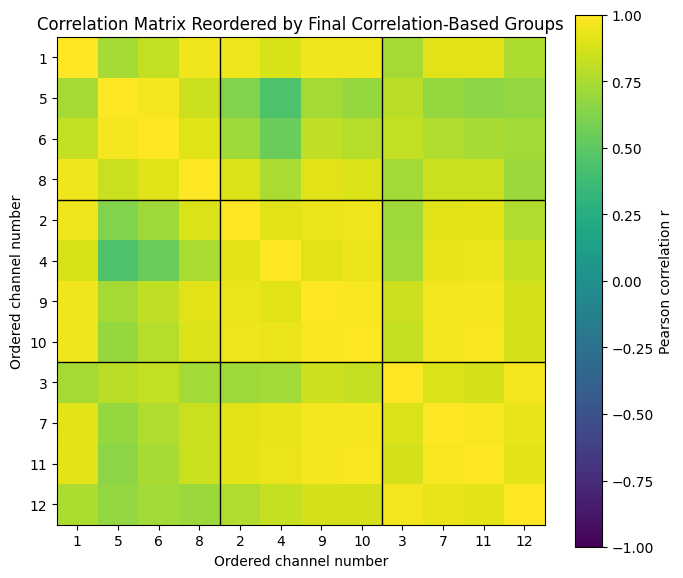

In [109]:
ordered_channels = [ch for group in corr_groups for ch in group]
ordered_channel_labels = [ch + 1 for ch in ordered_channels]

corr_reordered = corr_matrix[np.ix_(ordered_channels, ordered_channels)]

plt.figure(figsize=(7, 6))
im = plt.imshow(corr_reordered, vmin=-1, vmax=1, aspect="equal")
plt.colorbar(im, label="Pearson correlation r")
plt.title("Correlation Matrix Reordered by Final Correlation-Based Groups")
plt.xlabel("Ordered channel number")
plt.ylabel("Ordered channel number")
plt.xticks(range(n_channels), ordered_channel_labels)
plt.yticks(range(n_channels), ordered_channel_labels)

# Draw lines separating groups of four.
for boundary in [3.5, 7.5]:
    plt.axhline(boundary, color="black", linewidth=1)
    plt.axvline(boundary, color="black", linewidth=1)

plt.tight_layout()
plt.show()

The saved correlation grouping places channels 1, 5, 6, and 8 together; channels 2, 4, 9, and 10 together; and channels 3, 7, 11, and 12 together. Its within-group mean correlation is 0.9122, compared with 0.8085 between groups, a difference of 0.1037.

The stronger diagonal blocks are consistent with these measurements. High off-diagonal values also reveal substantial shared activity, so the grouping captures relative similarity within a broadly correlated recording.


### Independent-component comparison

PCA describes the variance structure before FastICA estimates three latent components. ICA provides a complementary view of the recording and a second candidate grouping to compare with the correlation solution.


The PCA variance profile tests whether variability is distributed across several dimensions or concentrated in a small number of dominant components.


PCA explained variance ratio:
PC1: 0.8534
PC2: 0.0825
PC3: 0.0497
PC4: 0.0042
PC5: 0.0017
PC6: 0.0015


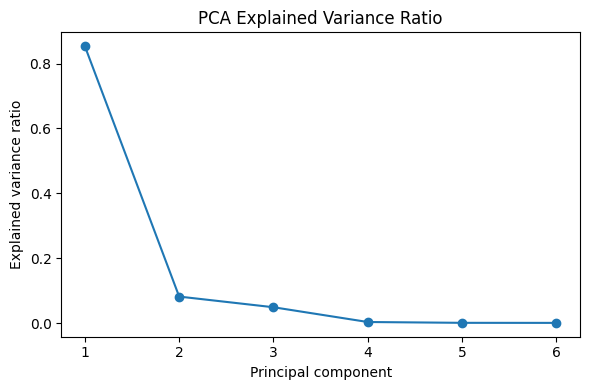

In [110]:
pca = PCA(n_components=6, random_state=RANDOM_STATE)
pca.fit(X_z.T)

print("PCA explained variance ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, 7), pca.explained_variance_ratio_, marker="o")
plt.title("PCA Explained Variance Ratio")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.xticks(np.arange(1, 7))
plt.tight_layout()
plt.show()

FastICA receives a samples-by-channels matrix and performs internal whitening. Three components reflect the assumed recording structure; the PCA calculation is a separate descriptive check.


In [111]:
# sklearn expects data shape: n_samples × n_features.
# Here, samples are time points and features are channels.
X_for_ica = X_z.T  # shape = 10000 × 12

ica = FastICA(
    n_components=3,
    random_state=RANDOM_STATE,
    whiten="unit-variance",
    max_iter=2000,
    tol=1e-4
)

S_ica = ica.fit_transform(X_for_ica)  # shape: time points × components
mixing_matrix = ica.mixing_          # shape: channels × components

print("ICA source matrix shape:", S_ica.shape)
print("ICA mixing matrix shape:", mixing_matrix.shape)


ICA source matrix shape: (10000, 3)
ICA mixing matrix shape: (12, 3)


Component time series show the temporal patterns recovered by FastICA. Their order and signs are arbitrary and do not identify anatomical sources.


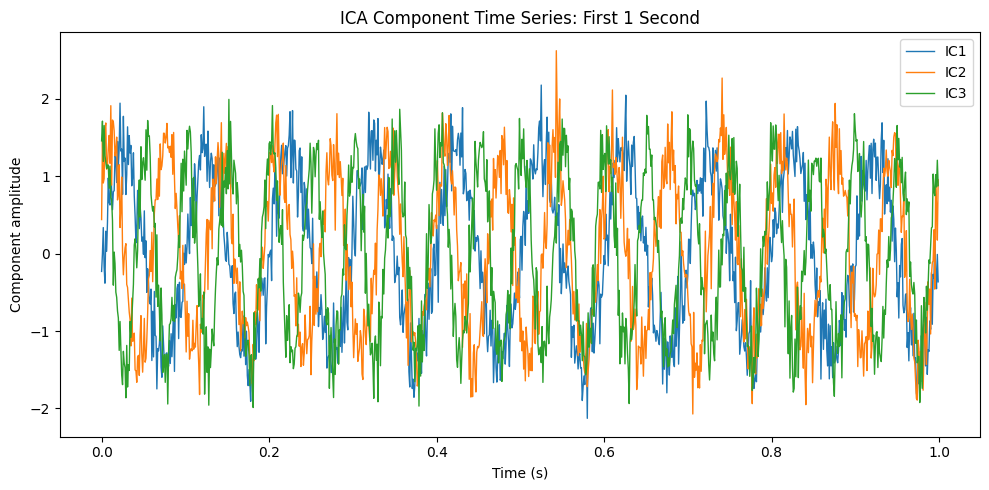

In [112]:
# Plot a representative 1-second segment of ICA components.
segment_start = 0.0
segment_end = 1.0
segment_mask = (time >= segment_start) & (time < segment_end)

plt.figure(figsize=(10, 5))
for comp in range(S_ica.shape[1]):
    plt.plot(time[segment_mask], S_ica[segment_mask, comp], label=f"IC{comp + 1}", linewidth=1)

plt.title("ICA Component Time Series: First 1 Second")
plt.xlabel("Time (s)")
plt.ylabel("Component amplitude")
plt.legend()
plt.tight_layout()
plt.show()

Absolute channel-to-component correlations measure association with each latent component. Assigning every channel to its strongest component can produce unequal group sizes. A Hungarian optimization with four slots per component enforces balanced groups while maximizing the combined association score.


Channel-to-IC correlation matrix shape: (12, 3)


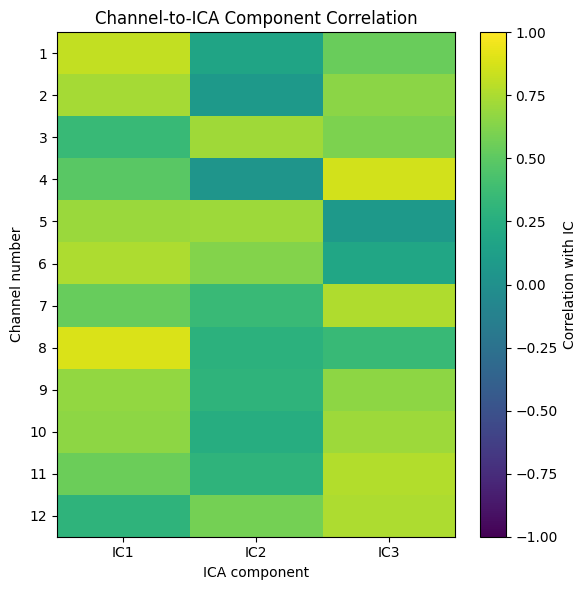

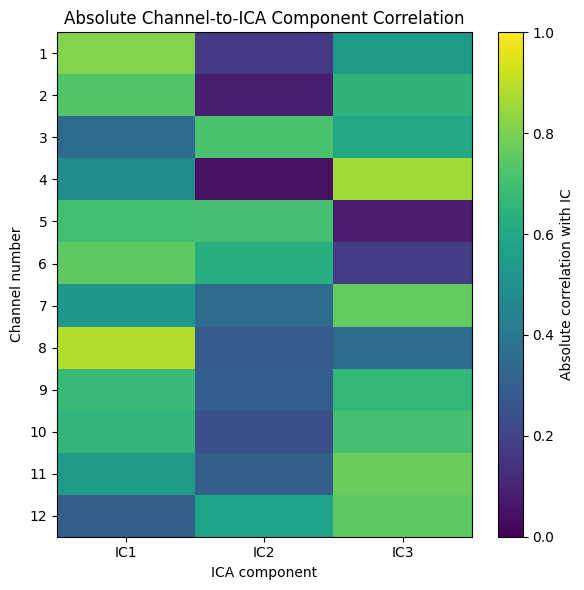

Naive ICA assignment based on dominant absolute channel-IC correlation (1-based channel numbers):
IC1: channels [1, 2, 6, 8, 9], size = 5
IC2: channels [3, 5], size = 2
IC3: channels [4, 7, 10, 11, 12], size = 5

Final balanced ICA-based grouping (channel numbers, 1-based):
IC Group 1: channels [1, 2, 8, 9]
IC Group 2: channels [3, 5, 6, 12]
IC Group 3: channels [4, 7, 10, 11]


In [113]:
# Compute correlation between original z-scored channels and ICA components.
# X_z shape: channels × time
# S_ica.T shape: components × time
channel_ic_corr = np.corrcoef(X_z, S_ica.T)[:n_channels, n_channels:]
channel_ic_abs_corr = np.abs(channel_ic_corr)

print("Channel-to-IC correlation matrix shape:", channel_ic_corr.shape)

channel_labels = np.arange(1, n_channels + 1)

plt.figure(figsize=(6, 6))
im = plt.imshow(channel_ic_corr, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, label="Correlation with IC")
plt.title("Channel-to-ICA Component Correlation")
plt.xlabel("ICA component")
plt.ylabel("Channel number")
plt.xticks(range(3), [f"IC{i+1}" for i in range(3)])
plt.yticks(range(n_channels), channel_labels)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
im = plt.imshow(channel_ic_abs_corr, vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, label="Absolute correlation with IC")
plt.title("Absolute Channel-to-ICA Component Correlation")
plt.xlabel("ICA component")
plt.ylabel("Channel number")
plt.xticks(range(3), [f"IC{i+1}" for i in range(3)])
plt.yticks(range(n_channels), channel_labels)
plt.tight_layout()
plt.show()


# Naive assignment: each channel goes to its strongest IC.
naive_ica_assignment = np.argmax(channel_ic_abs_corr, axis=1)

print("Naive ICA assignment based on dominant absolute channel-IC correlation (1-based channel numbers):")
for comp in range(3):
    group = sorted(np.where(naive_ica_assignment == comp)[0].tolist())
    group_1based = [ch + 1 for ch in group]
    print(f"IC{comp + 1}: channels {group_1based}, size = {len(group)}")


# Balanced ICA assignment:
# Each IC must receive exactly 4 channels.
def balanced_ica_assignment(score_matrix, group_size=4):
    """
    Assign each channel to one of 3 ICs, exactly 4 channels per IC.
    Uses Hungarian assignment by duplicating each IC label 4 times.
    """
    n_channels, n_components = score_matrix.shape
    slots = np.repeat(np.arange(n_components), group_size)

    if len(slots) != n_channels:
        raise ValueError("Number of slots must equal number of channels.")

    # Maximize score -> minimize negative score.
    cost_matrix = -score_matrix[:, slots]
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    assigned_component = np.empty(n_channels, dtype=int)
    for row, col in zip(row_ind, col_ind):
        assigned_component[row] = slots[col]

    groups = []
    for comp in range(n_components):
        groups.append(sorted(np.where(assigned_component == comp)[0].tolist()))

    return groups, assigned_component


ica_groups, balanced_ica_labels = balanced_ica_assignment(channel_ic_abs_corr, group_size=4)

print("\nFinal balanced ICA-based grouping (channel numbers, 1-based):")
for i, group in enumerate(ica_groups, start=1):
    group_1based = [ch + 1 for ch in group]
    print(f"IC Group {i}: channels {group_1based}")

The mixing-matrix heatmap shows relative component loadings across recording channels. Magnitudes are more informative for comparison than component signs or ordering.


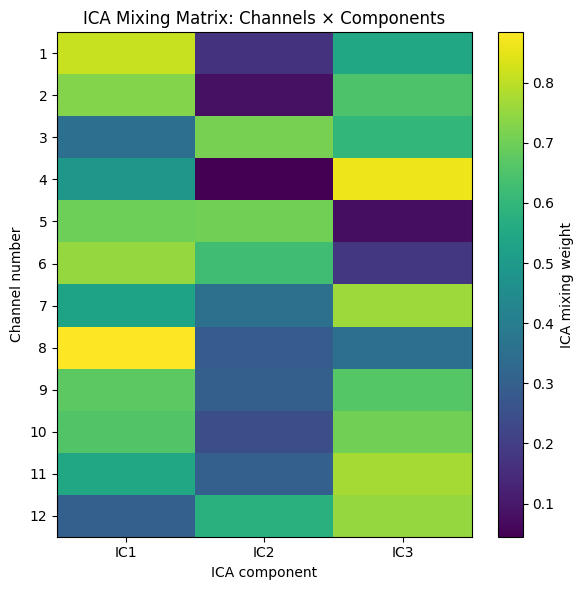

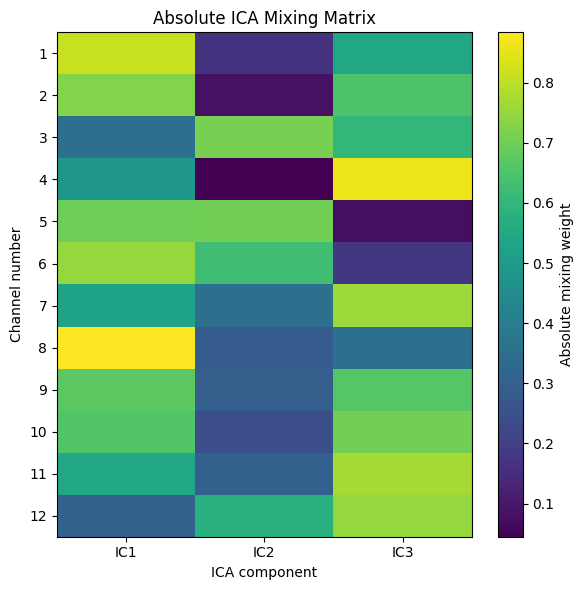

In [114]:
channel_labels = np.arange(1, n_channels + 1)

plt.figure(figsize=(6, 6))
im = plt.imshow(mixing_matrix, aspect="auto")
plt.colorbar(im, label="ICA mixing weight")
plt.title("ICA Mixing Matrix: Channels × Components")
plt.xlabel("ICA component")
plt.ylabel("Channel number")
plt.xticks(range(3), [f"IC{i+1}" for i in range(3)])
plt.yticks(range(n_channels), channel_labels)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
im = plt.imshow(np.abs(mixing_matrix), aspect="auto")
plt.colorbar(im, label="Absolute mixing weight")
plt.title("Absolute ICA Mixing Matrix")
plt.xlabel("ICA component")
plt.ylabel("Channel number")
plt.xticks(range(3), [f"IC{i+1}" for i in range(3)])
plt.yticks(range(n_channels), channel_labels)
plt.tight_layout()
plt.show()

The saved PCA profile is dominated by the first one or two components, consistent with strong shared structure. ICA associations are less clearly separated than a one-component-per-group interpretation would suggest, and the unconstrained assignment is unbalanced.

The balanced ICA solution groups channels **[1, 2, 8, 9]**, **[3, 5, 6, 12]**, and **[4, 7, 10, 11]**. Shared field-potential activity, common noise, and global components can weaken the statistical-independence assumption, so this solution is used as a comparison rather than an anatomical reference.


### Evaluating candidate groups

Within-group and between-group correlations quantify separation for each solution. Intra-versus-inter correlation is an internal separation metric, not independent anatomical validation, because the same recording is used to construct and evaluate the groups. Cross-method agreement provides an additional check on whether correlation grouping and ICA recover similar channel relationships.


Both signed and absolute Pearson correlations are summarized. Signed correlations remain the basis of the selection criterion, consistent with the correlation heatmap and the distance definition used above.


In [115]:
def validation_metrics(groups, corr_matrix, use_abs=True):
    """
    Compute average intra-group and inter-group correlations.
    If use_abs=True, use absolute Pearson correlation.
    If use_abs=False, use signed Pearson correlation.
    """
    M = np.abs(corr_matrix) if use_abs else corr_matrix
    n = M.shape[0]
    labels = labels_from_groups(groups, n)

    intra_vals = []
    inter_vals = []
    group_intra_means = []

    for group in groups:
        vals = []
        for i, j in itertools.combinations(group, 2):
            vals.append(M[i, j])
            intra_vals.append(M[i, j])
        group_intra_means.append(float(np.mean(vals)))

    for i, j in itertools.combinations(range(n), 2):
        if labels[i] != labels[j]:
            inter_vals.append(M[i, j])

    mean_intra = float(np.mean(intra_vals))
    mean_inter = float(np.mean(inter_vals))
    difference = mean_intra - mean_inter

    return {
        "mean_intra": mean_intra,
        "mean_inter": mean_inter,
        "difference": difference,
        "group_intra_means": group_intra_means,
    }


def print_validation_result(name, metrics):
    print(f"\n{name}")
    print("-" * len(name))
    print(f"Mean intra-group correlation: {metrics['mean_intra']:.4f}")
    print(f"Mean inter-group correlation: {metrics['mean_inter']:.4f}")
    print(f"Intra - inter difference: {metrics['difference']:.4f}")
    print("Group-level intra-group correlations:")
    for i, val in enumerate(metrics["group_intra_means"], start=1):
        print(f"  Group {i}: {val:.4f}")


corr_metrics_abs = validation_metrics(corr_groups, corr_matrix, use_abs=True)
ica_metrics_abs = validation_metrics(ica_groups, corr_matrix, use_abs=True)

corr_metrics_signed = validation_metrics(corr_groups, corr_matrix, use_abs=False)
ica_metrics_signed = validation_metrics(ica_groups, corr_matrix, use_abs=False)

print_validation_result("Correlation grouping validation using absolute r", corr_metrics_abs)
print_validation_result("ICA grouping validation using absolute r", ica_metrics_abs)

print_validation_result("Correlation grouping validation using signed r", corr_metrics_signed)
print_validation_result("ICA grouping validation using signed r", ica_metrics_signed)


Correlation grouping validation using absolute r
------------------------------------------------
Mean intra-group correlation: 0.9122
Mean inter-group correlation: 0.8085
Intra - inter difference: 0.1037
Group-level intra-group correlations:
  Group 1: 0.8694
  Group 2: 0.9388
  Group 3: 0.9283

ICA grouping validation using absolute r
----------------------------------------
Mean intra-group correlation: 0.9056
Mean inter-group correlation: 0.8110
Intra - inter difference: 0.0946
Group-level intra-group correlations:
  Group 1: 0.9335
  Group 2: 0.8255
  Group 3: 0.9578

Correlation grouping validation using signed r
----------------------------------------------
Mean intra-group correlation: 0.9122
Mean inter-group correlation: 0.8085
Intra - inter difference: 0.1037
Group-level intra-group correlations:
  Group 1: 0.8694
  Group 2: 0.9388
  Group 3: 0.9283

ICA grouping validation using signed r
--------------------------------------
Mean intra-group correlation: 0.9056
Mean inter

Group labels are arbitrary, so an overlap comparison searches permutations before reporting the best channel match. Adjusted Rand index measures agreement independently of group naming.


In [116]:
def best_group_matching(groups_a, groups_b):
    """
    Match groups_a to groups_b by maximum overlap.
    Group order is arbitrary, so this finds the best permutation.
    """
    n_groups = len(groups_a)
    overlap = np.zeros((n_groups, n_groups), dtype=int)

    for i, ga in enumerate(groups_a):
        set_a = set(ga)
        for j, gb in enumerate(groups_b):
            set_b = set(gb)
            overlap[i, j] = len(set_a.intersection(set_b))

    best_perm = None
    best_score = -1

    for perm in itertools.permutations(range(n_groups)):
        score = sum(overlap[i, perm[i]] for i in range(n_groups))
        if score > best_score:
            best_score = score
            best_perm = perm

    return overlap, best_perm, best_score


def to_1based(channel_list):
    return [ch + 1 for ch in channel_list]


corr_labels = labels_from_groups(corr_groups, n_channels)
ica_labels = labels_from_groups(ica_groups, n_channels)

ari = adjusted_rand_score(corr_labels, ica_labels)

overlap_matrix, best_perm, best_overlap = best_group_matching(corr_groups, ica_groups)

print("Overlap matrix between correlation groups and ICA groups:")
print(overlap_matrix)

print("\nBest group matching:")
for i, j in enumerate(best_perm):
    corr_set = set(corr_groups[i])
    ica_set = set(ica_groups[j])
    shared = sorted(corr_set.intersection(ica_set))
    only_corr = sorted(corr_set - ica_set)
    only_ica = sorted(ica_set - corr_set)

    print(f"Correlation Group {i + 1} ↔ ICA Group {j + 1}")
    print(f"  Shared channels: {to_1based(shared)}")
    print(f"  Only in correlation group: {to_1based(only_corr)}")
    print(f"  Only in ICA group: {to_1based(only_ica)}")

print(f"\nTotal matched overlap: {best_overlap} / {n_channels}")
print(f"Adjusted Rand Index between the two groupings: {ari:.4f}")

if best_overlap == n_channels:
    print("\nInterpretation: ICA and correlation clustering are fully consistent.")
elif best_overlap >= 10:
    print("\nInterpretation: ICA and correlation clustering are largely consistent, with minor channel differences.")
else:
    print("\nInterpretation: ICA and correlation clustering show notable differences.")

Overlap matrix between correlation groups and ICA groups:
[[2 2 0]
 [2 0 2]
 [0 2 2]]

Best group matching:
Correlation Group 1 ↔ ICA Group 1
  Shared channels: [1, 8]
  Only in correlation group: [5, 6]
  Only in ICA group: [2, 9]
Correlation Group 2 ↔ ICA Group 3
  Shared channels: [4, 10]
  Only in correlation group: [2, 9]
  Only in ICA group: [7, 11]
Correlation Group 3 ↔ ICA Group 2
  Shared channels: [3, 12]
  Only in correlation group: [7, 11]
  Only in ICA group: [5, 6]

Total matched overlap: 6 / 12
Adjusted Rand Index between the two groupings: 0.0833

Interpretation: ICA and correlation clustering show notable differences.


In [117]:
# Summarize validation metrics in a compact table.
# Signed Pearson r is used here to remain consistent with the correlation heatmap and D = 1 - r distance.

validation_summary = pd.DataFrame([
    {
        "Method": "Correlation-based balanced grouping",
        "Mean intra-group r": corr_metrics_signed["mean_intra"],
        "Mean inter-group r": corr_metrics_signed["mean_inter"],
        "Intra - inter difference": corr_metrics_signed["difference"],
    },
    {
        "Method": "Balanced ICA-based grouping",
        "Mean intra-group r": ica_metrics_signed["mean_intra"],
        "Mean inter-group r": ica_metrics_signed["mean_inter"],
        "Intra - inter difference": ica_metrics_signed["difference"],
    },
])

validation_summary

,Method,Mean intra-group r,Mean inter-group r,Intra - inter difference
0,Correlation-based balanced grouping,0.912172,0.808500,0.103672
1,Balanced ICA-based grouping,0.905580,0.810971,0.094609


The selection rule compares within-minus-between correlation differences. When the scores are close within the implemented tolerance of 0.02, it favors the correlation solution because that approach directly represents the similarity hypothesis. ICA remains a complementary comparison.


In [118]:
# Decision rule:
# 1. Prefer the grouping with stronger intra - inter separation.
# 2. If the two methods are very close, prefer correlation grouping because the analysis premise is based on channel similarity.
# 3. ICA is useful as a complementary comparison, but its components have sign and permutation ambiguity.
# 4. Signed Pearson r is used for the final decision to remain consistent with the heatmap and the D = 1 - r distance.

TOLERANCE = 0.02

corr_score = corr_metrics_signed["difference"]
ica_score = ica_metrics_signed["difference"]

if corr_score >= ica_score - TOLERANCE:
    final_groups = corr_groups
    final_method = "correlation-based balanced grouping"
    final_reason = (
        "The selected grouping shows stronger within-group than between-group "
        "correlation. The correlation-based balanced grouping is used as the final result because "
        "it directly follows the analysis assumption that channels in a candidate recording group should "
        "be highly correlated. Since ICA agreement is weak and inter-group correlations remain high, "
        "the result should be interpreted as a candidate recording-group organization rather than definitive anatomical proof."
    )
else:
    final_groups = ica_groups
    final_method = "balanced ICA-based grouping"
    final_reason = (
        "The balanced ICA-based grouping is used as the final result because it gives stronger "
        "intra-versus-inter group separation than the correlation-based grouping. Since ICA components "
        "have sign and permutation ambiguity, the result should still be interpreted cautiously."
    )

print("Final selected method:", final_method)
print(final_reason)

print("\nFinal channel grouping (channel numbers, 1-based):")
for i, group in enumerate(final_groups, start=1):
    group_1based = [ch + 1 for ch in group]
    print(f"Final Group {i}: channels {group_1based}")

Final selected method: correlation-based balanced grouping
The selected grouping shows stronger within-group than between-group correlation. The correlation-based balanced grouping is used as the final result because it directly follows the analysis assumption that channels in a candidate recording group should be highly correlated. Since ICA agreement is weak and inter-group correlations remain high, the result should be interpreted as a candidate recording-group organization rather than definitive anatomical proof.

Final channel grouping (channel numbers, 1-based):
Final Group 1: channels [1, 5, 6, 8]
Final Group 2: channels [2, 4, 9, 10]
Final Group 3: channels [3, 7, 11, 12]


## Results

### Group separation and agreement

| Method | Mean within-group r | Mean between-group r | Difference |
| --- | ---: | ---: | ---: |
| Correlation-based balanced grouping | 0.9122 | 0.8085 | 0.1037 |
| Balanced ICA grouping | 0.9056 | 0.8110 | 0.0946 |

The correlation solution has the larger separation score and is selected by the implemented rule. In one-based channel numbering, its groups are **[1, 5, 6, 8]**, **[2, 4, 9, 10]**, and **[3, 7, 11, 12]**.

The best cross-method match includes only **6 of 12 channels**, with an adjusted Rand index of **0.0833**. The two methods therefore recover substantially different groupings, despite both producing higher within-group than between-group correlations.


### Representative group signals

The selected groups are summarized by averaging their four standardized channels. These traces describe the grouping after selection and do not determine its membership.


The full 10-second view shows broad temporal patterns; a 1-second segment exposes shorter-timescale waveform differences. Averaging standardized channels prevents large raw amplitudes from dominating a group trace.


Group-averaged signal matrix shape: (3, 10000)


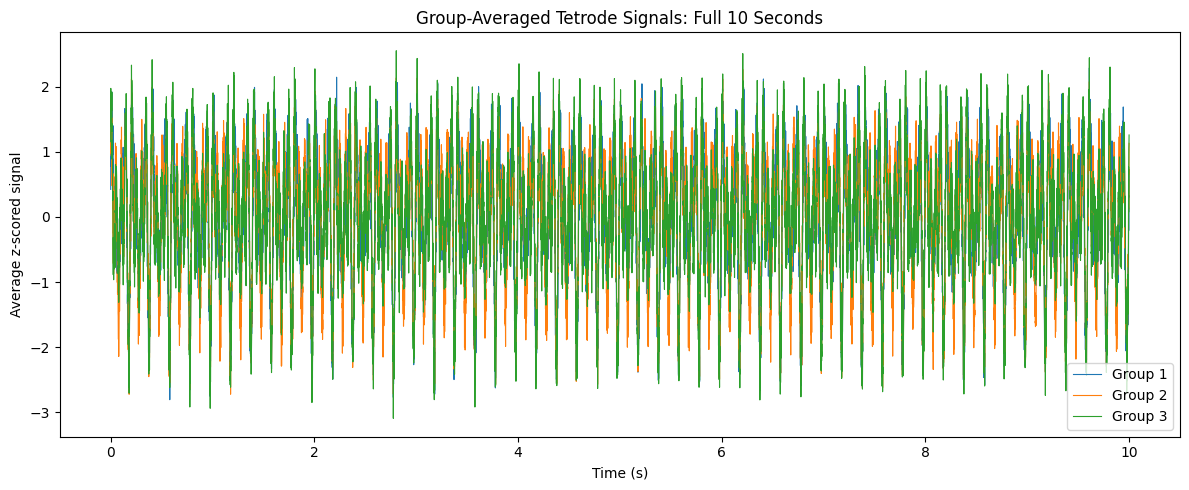

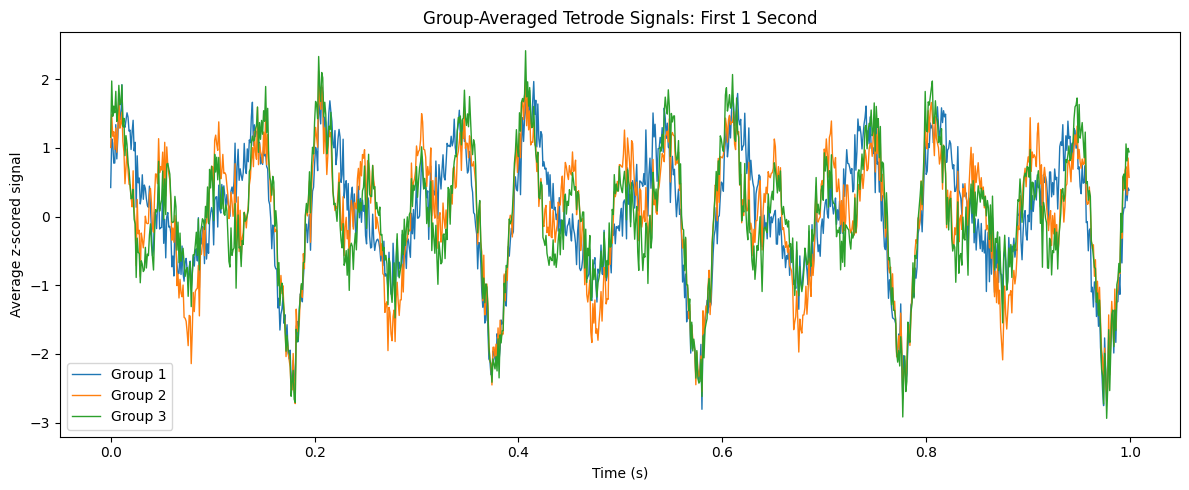

In [119]:
# Average the four z-scored channels within each final group.
# Z-scored signals are used so that one high-amplitude channel does not dominate the average.
group_signals = []

for group in final_groups:
    group_signal = X_z[group, :].mean(axis=0)
    group_signals.append(group_signal)

group_signals = np.array(group_signals)

print("Group-averaged signal matrix shape:", group_signals.shape)

# Plot full 10-second averaged signals.
plt.figure(figsize=(12, 5))
for i in range(group_signals.shape[0]):
    plt.plot(time, group_signals[i], label=f"Group {i + 1}", linewidth=0.8)

plt.title("Group-Averaged Tetrode Signals: Full 10 Seconds")
plt.xlabel("Time (s)")
plt.ylabel("Average z-scored signal")
plt.legend()
plt.tight_layout()
plt.show()

# Plot representative 1-second segment.
segment_start = 0.0
segment_end = 1.0
segment_mask = (time >= segment_start) & (time < segment_end)

plt.figure(figsize=(12, 5))
for i in range(group_signals.shape[0]):
    plt.plot(time[segment_mask], group_signals[i, segment_mask], label=f"Group {i + 1}", linewidth=1)

plt.title("Group-Averaged Tetrode Signals: First 1 Second")
plt.xlabel("Time (s)")
plt.ylabel("Average z-scored signal")
plt.legend()
plt.tight_layout()
plt.show()

The three group averages provide compact representations of the candidate recording groups. They support visual comparison of temporal patterns, while their anatomical interpretation remains conditional on the grouping assumptions.


### Spectral characteristics

Welch power spectral density estimates describe how the variance of each group average is distributed across frequency.


The spectra are plotted over 0–150 Hz. Peak reporting searches 1–100 Hz for the strongest component in each group average.


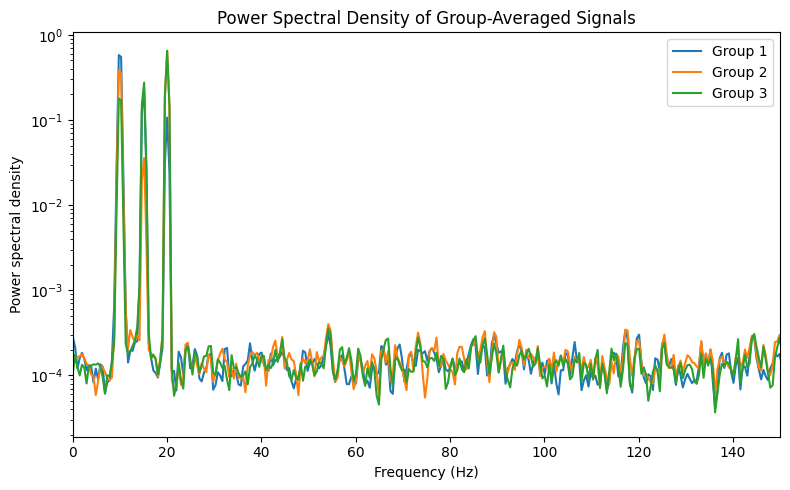

Dominant frequency between 1 and 100 Hz:
Group 1: peak frequency = 9.77 Hz, peak power = 0.579318
Group 2: peak frequency = 20.02 Hz, peak power = 0.651208
Group 3: peak frequency = 20.02 Hz, peak power = 0.649468


In [120]:
psd_results = []

plt.figure(figsize=(8, 5))

for i in range(group_signals.shape[0]):
    f, pxx = signal.welch(
        group_signals[i],
        fs=FS,
        nperseg=min(2048, n_timepoints),
        noverlap=min(1024, n_timepoints // 2),
        detrend="constant"
    )

    psd_results.append((f, pxx))
    plt.semilogy(f, pxx, label=f"Group {i + 1}")

plt.title("Power Spectral Density of Group-Averaged Signals")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.xlim(0, 150)
plt.legend()
plt.tight_layout()
plt.show()

# Report dominant frequency between 1 and 100 Hz for each group.
print("Dominant frequency between 1 and 100 Hz:")
for i, (f, pxx) in enumerate(psd_results, start=1):
    valid = (f >= 1) & (f <= 100)
    peak_freq = f[valid][np.argmax(pxx[valid])]
    peak_power = np.max(pxx[valid])
    print(f"Group {i}: peak frequency = {peak_freq:.2f} Hz, peak power = {peak_power:.6f}")

The dominant frequencies are **9.77 Hz** for Group 1 and **20.02 Hz** for Groups 2 and 3. These peaks suggest differences in rhythmic or spectral characteristics between the candidate groups. Spectra are descriptive measurements obtained after grouping; they do not replace the correlation comparison or independently validate group membership.


## Limitations

The correlation solution is the preferred candidate because it directly represents the similarity hypothesis and has the larger within-minus-between separation. The measurements support relative channel organization, but they do not provide definitive anatomical identification.

Nearby tetrode contacts can sample overlapping tissue and share local field potentials, multi-unit activity, and background noise, making strong within-group similarity plausible. The between-group mean correlation above 0.8 also indicates a broad common component. Shared rhythms, reference effects, or common-mode noise are possible contributors; this analysis does not distinguish them conclusively.

The dominant PCA components and weak ICA agreement limit confidence in three independently separable sources. ICA assumes statistical independence and has sign and permutation ambiguities. The balanced methods additionally impose three groups of four, so equal group size is an analysis constraint rather than independent evidence of anatomy.

Group averages and their PSD peaks summarize the selected solution without establishing its biological identity. The defensible conclusion is a candidate organization of the tetrode channels that shows stronger within-group than between-group correlation, with substantial shared activity and limited agreement across methods. This provides an internal consistency measure rather than independent anatomical validation.

The notebook was checked top-to-bottom in a fresh kernel using the available local recording, without global warning suppression. No notebook warnings or execution errors were emitted, and the reported numerical values matched the saved outputs. Saved figures and numerical results are retained; a different recording would produce different results.
